# Invariant EKF for Attitude Estimation on SO(3)

*A group-affine alternative to the classical multiplicative EKF for gyroscope + accelerometer + magnetometer attitude fusion.*


## Author

Drafted with an AI pair-programming assistant (Claude), based on a MATLAB
reference implementation and benchmark developed over the course of this
project. Review, correction, and attribution by the human contributor
before merging.


## Goal

- Estimate the attitude $R \in SO(3)$ of a rigid body (body $\to$ world
  rotation) from a gyroscope, an accelerometer, and a magnetometer, using
  an **Invariant Extended Kalman Filter** ($IEKF$) formulated directly on
  the Lie group $SO(3)$, with the gyro bias as an explicit additional
  state.
- Show, with an exact synthetic ground truth, that the $IEKF$'s defining
  theoretical property — propagation Jacobians that do not depend on the
  estimated state — translates into fast, reliable recovery from a poor
  initial attitude estimate, and into unbiased gyro-bias estimation.
- Present the class in the same predict/update pattern as
  `c4dynamics.filters.kalman` / `c4dynamics.filters.ekf`, so it can slot
  into `c4dynamics.filters` as a sibling of `ekf`.


## Overview

A classical (multiplicative) $EKF$ for attitude linearizes the error
between the true and estimated rotation around the *current estimate*,
so its propagation Jacobian depends on that estimate. If the estimate is
badly wrong — after a cold start, a sensor dropout, or a hand-off between
subsystems — the linearization is evaluated in the wrong place, the
reported covariance becomes inconsistent with the true error, and the
filter can take many seconds to recover, or fail to recover at all.

The Invariant EKF avoids this by defining the attitude error through the
*group action* on $SO(3)$ rather than by subtraction, exploiting the fact
that gyro-driven attitude propagation is **group-affine**: the error
dynamics are governed by the *measured* angular rate alone, never by the
*estimated* attitude. The propagation Jacobian is therefore correct
regardless of how wrong the current estimate is — which is exactly the
regime a cold start or a sensor dropout puts the filter in.

This notebook builds the theory from the ground up (§2–§5), gives a
`c4dynamics`-style implementation (§6), and then demonstrates the claim
quantitatively against an exact synthetic ground truth (§7–§8): nominal
accuracy, recovery from a $90°$ initial attitude error, and gyro-bias
convergence, closing with a filter-consistency check (NEES).


## Table of Contents

1. [Setup](#1.-Setup)
2. [The Estimation Problem](#2.-The-Estimation-Problem)
3. [Coordinate Frames and Attitude Kinematics on SO(3)](#3.-Coordinate-Frames-and-Attitude-Kinematics-on-SO(3))
4. [Sensors — The Measurements](#4.-Sensors-—-The-Measurements)
5. [Invariant Extended Kalman Filter](#5.-Invariant-Extended-Kalman-Filter)
   - 5.1 [Process Model — The Predict Stage](#5.1.-Process-Model-—-The-Predict-Stage)
   - 5.2 [Measurement Model — The Update Stage](#5.2.-Measurement-Model-—-The-Update-Stage)
6. [C4DYNAMICS — Implementation](#6.-C4DYNAMICS-—-Implementation)
7. [Simulation](#7.-Simulation)
8. [Results](#8.-Results)
9. [Summary & Conclusions](#9.-Summary-&-Conclusions)


## 1. Setup

This notebook is **self-contained**: it does not import `c4dynamics`, so
it runs anywhere with `numpy` and `matplotlib`. §6 shows the
`c4dynamics.filters`-style class (subclassing `kalman`, matching
`ekf.py`'s conventions) as a code listing — that is the version intended
to become `c4dynamics.filters.iekf`. The class actually *executed* in
this notebook (§6, second code cell) is a plain-`numpy` equivalent of the
identical algorithm, so the notebook has no external dependency beyond
the scientific Python stack.

**Minimum `c4dynamics` version**: not applicable yet — the
`c4dynamics.filters`-style class in §6 is a proposed addition (`iekf`,
sibling of `ekf`), not yet merged. Once merged, this note should state
the first release containing it.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

np.random.seed(11)
print("numpy", np.__version__)

numpy 2.3.1


## 2. The Estimation Problem

The attitude of a rigid body is the rotation $R$ that maps a vector
expressed in the body frame to the same vector expressed in the world
frame: $\mathbf v_{world} = R\,\mathbf v_{body}$. $R$ is not observed
directly; it is reconstructed from:

- a rate **gyroscope**, which measures the body's angular velocity
  $\boldsymbol\omega$ (corrupted by noise and a slowly-varying bias), and
- an **accelerometer** and a **magnetometer**, which measure two
  known world-frame reference directions (gravity and the local magnetic
  field) as seen in the body frame — together they make the full
  $3$-DOF attitude observable (the accelerometer alone only constrains
  $2$ of the $3$ degrees of freedom: it fixes "up", not heading).

**Why not just treat $R$ (or a $3$-vector encoding of it) as a linear
Kalman state?** $R$ is constrained to $SO(3) = \{R \in \mathbb
R^{3\times3} : R^\top R = I,\ \det R = 1\}$ — a curved manifold, not a
vector space. $R_{true} - R_{est}$ is in general **not itself a valid
rotation**, so it cannot serve as an estimation error the way a plain
subtraction does for a position or velocity state. §3 develops the tool
that replaces subtraction on this manifold.


## 3. Coordinate Frames and Attitude Kinematics on SO(3)

**Coordinate frames used in this notebook:**

- **Body frame** $\mathcal B$: fixed to the rigid body; origin at its
  center of mass; axes aligned with the IMU's own sensing axes. Not
  otherwise constrained (this notebook's synthetic sensors are generated
  directly in this frame, so no physical axis convention is assumed).
- **World frame** $\mathcal W$: an inertial reference frame in which
  gravity and the local magnetic field are constant, known vectors. Its
  origin and orientation are arbitrary but fixed for the duration of a
  run (in §7, $\mathcal W$ is defined by the two reference directions
  `gRef`, `mRef`).

**Attitude and its rate of change.** The state is $R \in SO(3)$, the
rotation from $\mathcal B$ to $\mathcal W$. Given the body-frame angular
velocity $\boldsymbol\omega(t) \in \mathbb R^3$ measured by the
gyroscope, $R$ evolves as

$$\dot R = R\,[\boldsymbol\omega]_\times,$$

where $[\boldsymbol\omega]_\times$ is the *skew-symmetric matrix*
associated with $\boldsymbol\omega$, defined so that
$[\boldsymbol\omega]_\times \mathbf v = \boldsymbol\omega \times \mathbf
v$ for any $\mathbf v \in \mathbb R^3$. This is the isomorphism between
$\mathbb R^3$ and $\mathfrak{so}(3)$, the *Lie algebra* of $SO(3)$ — the
vector space tangent to $SO(3)$ at the identity.

**The exponential map.** A constant angular velocity applied for a
duration equal to the norm of a rotation vector $\boldsymbol\phi \in
\mathbb R^3$ (direction = rotation axis, norm = rotation angle in
radians) produces the rotation

$$\exp(\boldsymbol\phi) = I + \sin(\theta)K + (1-\cos\theta)K^2,
\qquad K = [\boldsymbol\phi/\theta]_\times,\ \ \theta = \|\boldsymbol\phi\|$$

(Rodrigues' formula). This *exponential map* $\exp: \mathfrak{so}(3) \to
SO(3)$ is what replaces vector addition when moving a rotation by a
small increment: instead of $R + \delta$ (not defined), we use $R\cdot
\exp(\boldsymbol\phi)$, which is always a valid rotation. Its inverse,
$\log: SO(3) \to \mathfrak{so}(3)$, recovers $\boldsymbol\phi$ from a
rotation matrix; $\|\log(R)\|$ is the **geodesic distance** on $SO(3)$
between $R$ and the identity — the metric used throughout this notebook
to report attitude error, since it has no gimbal-lock artifact and no
dependence on an arbitrary Euler sequence.

**Discrete propagation.** Over a short sample interval $\Delta t$, with
$\boldsymbol\omega$ measured (and hence held constant over the interval),

$$R_{k+1} = R_k \cdot \exp(\boldsymbol\omega_k\,\Delta t).$$

This integrates the kinematics *exactly* on the group (no small-angle
approximation, no re-normalization needed) — the code cell below
implements `skewSym`, `expSO3`, `logSO3` and checks the round-trip
$\exp(\log(R)) = R$.


In [2]:
def skewSym(v):
    '''Skew-symmetric matrix [v]_x such that skewSym(v) @ w == cross(v, w).'''
    v = np.asarray(v, dtype=float).ravel()
    return np.array([[0.0, -v[2], v[1]],
                      [v[2], 0.0, -v[0]],
                      [-v[1], v[0], 0.0]])

def expSO3(phi):
    '''Exponential map so(3) -> SO(3) (Rodrigues' formula).'''
    phi = np.asarray(phi, dtype=float).ravel()
    t = np.linalg.norm(phi)
    if t < 1e-9:
        return np.eye(3) + skewSym(phi)
    K = skewSym(phi / t)
    return np.eye(3) + np.sin(t) * K + (1 - np.cos(t)) * (K @ K)

def logSO3(R):
    '''Logarithm map SO(3) -> so(3). ||logSO3(R)|| is the geodesic
    (total rotation angle) distance between R and the identity.'''
    R = np.asarray(R, dtype=float)
    c = np.clip((np.trace(R) - 1) / 2, -1.0, 1.0)
    t = np.arccos(c)
    if t < 1e-9:
        return np.zeros(3)
    if abs(t - np.pi) < 1e-6:
        A = (R + np.eye(3)) / 2
        ax = np.sqrt(np.maximum(np.diag(A), 0.0))
        imax = int(np.argmax(ax))
        v = np.array([R[2,1]-R[1,2], R[0,2]-R[2,0], R[1,0]-R[0,1]])
        if abs(v[imax]) > 1e-12 and ax[imax] > 0:
            ax = ax * np.sign(v[imax])
        return t * ax / np.linalg.norm(ax)
    v = np.array([R[2,1]-R[1,2], R[0,2]-R[2,0], R[1,0]-R[0,1]])
    return (t / (2*np.sin(t))) * v

# sanity check: exp(log(R)) == R for a generic rotation
R_test = expSO3(np.array([0.3, -0.5, 0.2]))
roundtrip_err = np.linalg.norm(expSO3(logSO3(R_test)) - R_test)
print(f"round-trip error: {roundtrip_err:.2e}  (should be ~1e-16)")

round-trip error: 1.52e-16  (should be ~1e-16)


## 4. Sensors — The Measurements

### 4.1. Gyroscope

$$\boldsymbol\omega_{meas}(t) = \boldsymbol\omega_{true}(t) + \mathbf b(t) + \mathbf n_g(t)$$

where $\boldsymbol\omega_{true}$ is the true body-frame angular velocity
$[rad/s]$, $\mathbf b(t)$ is a slowly time-varying bias $[rad/s]$
(modeled as a random walk, $\dot{\mathbf b} = \mathbf n_b$), and
$\mathbf n_g \sim \mathcal N(0, \sigma_{gyro}^2 I)$ is white measurement
noise.

### 4.2. Accelerometer

With no linear acceleration (or when it is small relative to gravity),
the accelerometer measures the direction of gravity as seen in the body
frame:

$$\mathbf a_{meas} = R^\top \mathbf g_{ref} + \mathbf n_a, \qquad
\mathbf n_a \sim \mathcal N(0, \sigma_{acc}^2 I)$$

where $\mathbf g_{ref}$ is the (constant, known) gravity direction in
the world frame $\mathcal W$. This single vector observation constrains
$2$ of the $3$ attitude degrees of freedom (it cannot see rotation about
its own axis) — the classical "roll/pitch from accelerometer, yaw needs
something else" statement.

### 4.3. Magnetometer

$$\mathbf m_{meas} = R^\top \mathbf m_{ref} + \mathbf n_m, \qquad
\mathbf n_m \sim \mathcal N(0, \sigma_{mag}^2 I)$$

with $\mathbf m_{ref}$ the local magnetic field direction in
$\mathcal W$. Combined with the accelerometer (two non-parallel
reference vectors), the full $3$-DOF attitude becomes observable.

### 4.4. Summary

| Sensor | Measures | World-frame reference | Constrains |
|---|---|---|---|
| Gyroscope | $\boldsymbol\omega + \mathbf b$ | — | propagation only |
| Accelerometer | $R^\top \mathbf g_{ref}$ | gravity direction | roll, pitch |
| Magnetometer | $R^\top \mathbf m_{ref}$ | magnetic field direction | yaw |

The code cell below defines the sensor-generation function used
throughout §7–§8; it is exercised there, not here.


In [3]:
def simulate_sensors(Rtrue, wTrue, gRef, mRef, gyroBias,
                      sigmaGyro, sigmaAcc, sigmaMag, rng):
    '''Generate gyro/acc/mag samples for an exact ground-truth Rtrue(t), wTrue(t).'''
    N = Rtrue.shape[2]
    gyro = np.zeros((3, N)); acc = np.zeros((3, N)); mag = np.zeros((3, N))
    for k in range(N):
        gyro[:, k] = wTrue[:, k] + gyroBias + sigmaGyro * rng.standard_normal(3)
        acc[:, k]  = Rtrue[:, :, k].T @ gRef + sigmaAcc * rng.standard_normal(3)
        mag[:, k]  = Rtrue[:, :, k].T @ mRef + sigmaMag * rng.standard_normal(3)
    return gyro, acc, mag

def direction_noise_std(v):
    '''Empirical std of a vector's DIRECTION (not magnitude), from static
    samples: scatter of the normalised vectors in the plane tangent to their
    mean direction, split over its 2 degrees of freedom. This is what
    sigmaAcc/sigmaMag represent in the measurement model above (noise on the
    *normalised* vector), not std(norm(v)), which measures a different,
    radial quantity.'''
    u = v / np.linalg.norm(v, axis=0)
    uMean = u.mean(axis=1); uMean = uMean / np.linalg.norm(uMean)
    r = u - (uMean @ u) * uMean[:, None]
    return np.sqrt(np.mean(np.sum(r**2, axis=0)) / 2)

print("sensor model functions defined")

sensor model functions defined


## 5. Invariant Extended Kalman Filter

The estimation error is defined through the group action instead of
subtraction, as a body-frame ("left-invariant") error:

$$R_{true} = \hat R \cdot \exp(\boldsymbol\delta) \qquad\Longleftrightarrow\qquad
\boldsymbol\delta = \log\!\left(\hat R^\top R_{true}\right)$$

where $\hat R$ is the current estimate and $\boldsymbol\delta \in
\mathbb R^3$ is the error expressed in the Lie algebra $\mathfrak{so}(3)
\cong \mathbb R^3$ — which *is* a vector space, so the standard
Gaussian/Kalman machinery (means, covariances, linear updates) applies
to $\boldsymbol\delta$ consistently.

The error state augments $\boldsymbol\delta$ with the gyro-bias error
$\boldsymbol\beta = \mathbf b_{true} - \hat{\mathbf b}$:

$$\mathbf x = \begin{bmatrix}\boldsymbol\delta \\ \boldsymbol\beta\end{bmatrix} \in \mathbb R^6$$


### 5.1. Process Model — The Predict Stage

Differentiating the error definition above along the true and estimated
dynamics gives the **linearized** error dynamics

$$\dot{\boldsymbol\delta} = -[\hat{\boldsymbol\omega}]_\times \boldsymbol\delta -
\boldsymbol\beta - \mathbf n_g, \qquad \dot{\boldsymbol\beta} = \mathbf n_b$$

where $\hat{\boldsymbol\omega} = \boldsymbol\omega_{meas} -
\hat{\mathbf b}$ is the bias-corrected measured rate. **This is the
group-affine property**: the transition depends only on
$\hat{\boldsymbol\omega}$ — a *measured* quantity — never on $\hat R$
itself. The discrete transition Jacobian is therefore

$$F_k = \begin{bmatrix} \exp(-\hat{\boldsymbol\omega}_k \Delta t) & -I\,\Delta t \\ 0 & I \end{bmatrix}, \qquad
P_{k+1}^- = F_k P_k F_k^\top + Q_k$$

with $Q_k = \mathrm{blkdiag}(\sigma_{gyro}^2 I,\ \sigma_{bias}^2 I)\,\Delta t$.
The nominal state itself is propagated *exactly* on the group (§3):

$$\hat R_{k+1}^- = \hat R_k \cdot \exp(\hat{\boldsymbol\omega}_k \Delta t), \qquad
\hat{\mathbf b}_{k+1}^- = \hat{\mathbf b}_k$$


### 5.2. Measurement Model — The Update Stage

For a known world-frame reference vector $\mathbf v_{ref}$ (gravity or
magnetic field) observed in the body frame,

$$\mathbf y = R^\top \mathbf v_{ref} + \text{noise}, \qquad
\hat{\mathbf y} = \hat R^\top \mathbf v_{ref}$$

Linearizing $\mathbf y - \hat{\mathbf y}$ in $\boldsymbol\delta$ gives

$$\mathbf y - \hat{\mathbf y} \approx [\hat{\mathbf y}]_\times \boldsymbol\delta + \text{noise}
\qquad\Longrightarrow\qquad H = \begin{bmatrix}[\hat{\mathbf y}]_\times & 0\end{bmatrix}$$

and the standard Kalman correction follows:

$$K = P H^\top (H P H^\top + R_{meas})^{-1}, \qquad
\begin{bmatrix}\hat{\boldsymbol\delta}\\\hat{\boldsymbol\beta}\end{bmatrix} = K(\mathbf y - \hat{\mathbf y})$$

**Injection.** Unlike a linear Kalman filter, the correction is not
added to the state — it is *injected* through the exponential map, which
is what keeps $\hat R$ a valid rotation at every step:

$$\hat R \leftarrow \hat R \cdot \exp(\hat{\boldsymbol\delta}), \qquad
\hat{\mathbf b} \leftarrow \hat{\mathbf b} + \hat{\boldsymbol\beta}$$

followed by the usual covariance update (Joseph form, for numerical
robustness) and, critically, a **reset of the error state to zero** —
see §6 for why this matters when built on top of a generic linear-Kalman
base class.

The accelerometer and magnetometer are each applied as a **separate,
sequential** vector update at every step (accelerometer, then
magnetometer): each individually constrains only part of the attitude
(§4), and processing them one at a time keeps every update a plain
$3$-dimensional linear correction.


## 6. C4DYNAMICS — Implementation

`c4dynamics.filters.kalman` provides the linear predict/update machinery
(`self.X`, `self.F`, `self.H`, `self.P`, `self.Q`, `self.R`);
`c4dynamics.filters.ekf` extends it for a nonlinear *vector* state via a
derivative `fx`. Neither fits a group-valued state directly — $\hat R$
cannot be added to a plain array the way `ekf.predict(fx=...)` adds a
vector derivative.

**The pattern used here (an error-state Kalman filter):** the *nominal*
state — the rotation `self.Rot` and the bias `self.b` — is kept as a
plain attribute on the object, separate from `self.X`. `self.X` is what
`kalman` actually manages: the Lie-algebra error state
$[\boldsymbol\delta;\boldsymbol\beta]$, always zero-mean. `predict()`
advances `self.Rot` on the group directly and lets the parent grow only
`self.P`; `update()` lets the parent compute the Kalman gain and update
`self.X`, then *injects* the result into `self.Rot`/`self.b` via
`expSO3` and resets `self.X` back to zero. This mirrors how `ekf`
accommodates a nonlinear vector field, except the nonlinearity here is
the group structure of $SO(3)$ rather than a nonlinear vector function.

Three points confirmed against the real `kalman.py` source during
development, worth carrying into a review of the class:

1. **Naming**: `kalman` already uses `self.R` for the measurement noise
   covariance (its `R` constructor argument) — the rotation is kept on
   `self.Rot` to avoid silently clobbering it.
2. **Scalar `P0`**: the parent does *not* auto-expand a bare scalar to
   `scalar * eye(n)` for `n > 1` (`np.atleast_2d(scalar)` gives a
   `(1, 1)` matrix regardless of `n`) — the class expands it itself
   before construction.
3. **Covariance form**: `kalman.update()` uses the textbook form `P = P
   - K@H@P`, not Joseph form. Mathematically equivalent for an exact
   `K`, but Joseph form stays positive-semidefinite under roundoff and
   the textbook form does not necessarily — relevant precisely in the
   large-correction regime (§8.2). Set `P_jitter` (a `kalman`
   constructor option) when using this class for that kind of scenario.

```python
class iekf(kalman):
    '''Invariant Extended Kalman Filter for attitude estimation on SO(3).'''

    def __init__(self, R0=None, b0=None, estimate_bias=True, P0=1.0,
                 sigmaGyro=np.deg2rad(0.5), sigmaBias=1e-3, P_jitter=None):
        self.Rot = np.eye(3) if R0 is None else np.array(R0, dtype=float, copy=True)
        self.b = np.zeros(3) if b0 is None else np.array(b0, dtype=float).ravel().copy()
        self._estimateBias = bool(estimate_bias)
        self._sigmaGyro, self._sigmaBias = sigmaGyro, sigmaBias

        X = ({"dthx":0.,"dthy":0.,"dthz":0.,"bx":0.,"by":0.,"bz":0.} if estimate_bias
             else {"dthx":0.,"dthy":0.,"dthz":0.})
        n = len(X)
        if np.isscalar(P0):                       # see point 2 above
            P0 = float(P0) * np.eye(n)
        super().__init__(X, np.eye(n), np.zeros((3, n)), P0=P0, P_jitter=P_jitter)

    def predict(self, gyro, dt, sigmaGyro=None, sigmaBias=None):
        om = np.asarray(gyro, dtype=float).ravel() - self.b
        self.Rot = self.Rot @ expSO3(om * dt)
        # ... build F, Q per Sec. 5.1 ...
        self.F = F
        super().predict(Q=Q)
        self.X *= 0.0                              # redundant but self-documenting

    def update(self, y, ref, Rmeas, adaptive=False, tol=0.05, nominalNorm=1.0, gate=None):
        # ... build H, innovation per Sec. 5.2 ...
        self.H = H
        K = super().update(innov=innov, R=Rm, gate=gate)
        if K is None:
            return None
        dx = np.asarray(self.X, dtype=float).ravel().copy()
        self.Rot = self.Rot @ expSO3(dx[0:3])
        if self._estimateBias:
            self.b = self.b + dx[3:6]
        self.X *= 0.0                              # inject-then-reset
        return K
```

*(Full docstrings and the adaptive-gating logic omitted here for length;
see the standalone `iekf.py` module for the complete, c4dynamics-verified
version.)*

**For this notebook's own execution** (no `c4dynamics` dependency), the
cell below defines a plain-`numpy` class implementing the identical
algorithm end to end — same equations, same injection-then-reset
pattern, same interface shape (`predict(gyro, dt)`,
`update(y, ref, Rmeas, adaptive=...)`).


In [4]:
class IEKF:
    '''Invariant EKF for attitude on SO(3), standalone (no c4dynamics
    dependency) -- identical algorithm to the c4dynamics-style class in
    the listing above; see Sec. 5 for the equations.'''

    def __init__(self, R0=None, b0=None, P0=1.0,
                 sigmaGyro=np.deg2rad(0.5), sigmaBias=1e-3):
        self.Rot = np.eye(3) if R0 is None else np.array(R0, dtype=float, copy=True)
        self.b = np.zeros(3) if b0 is None else np.array(b0, dtype=float).copy()
        self.sigmaGyro = sigmaGyro
        self.sigmaBias = sigmaBias
        self.P = (float(P0) * np.eye(6)) if np.isscalar(P0) else np.array(P0, dtype=float)

    def predict(self, gyro, dt):
        om = np.asarray(gyro, dtype=float).ravel() - self.b
        self.Rot = self.Rot @ expSO3(om * dt)

        F = np.eye(6)
        F[0:3, 0:3] = expSO3(-om * dt)
        F[0:3, 3:6] = -np.eye(3) * dt
        Q = np.zeros((6, 6))
        Q[0:3, 0:3] = (self.sigmaGyro**2) * np.eye(3) * dt
        Q[3:6, 3:6] = (self.sigmaBias**2) * np.eye(3) * dt

        self.P = F @ self.P @ F.T + Q

    def update(self, y, ref, Rmeas, adaptive=False, tol=0.05, nominalNorm=1.0):
        y = np.asarray(y, dtype=float).ravel()
        nrm = np.linalg.norm(y)
        if nrm < 1e-12:
            return None
        refDir = np.asarray(ref, dtype=float).ravel()
        refDir = refDir / np.linalg.norm(refDir)

        yhat = self.Rot.T @ refDir
        yMeas = y / nrm

        H = np.zeros((3, 6))
        H[:, 0:3] = skewSym(yhat)

        Rm = np.array(Rmeas, dtype=float, copy=True)
        if adaptive:
            dev = abs(nrm - nominalNorm) / nominalNorm
            Rm = Rm * (1 + (dev / tol) ** 2)

        S = H @ self.P @ H.T + Rm
        K = self.P @ H.T @ np.linalg.inv(S)
        dx = K @ (yMeas - yhat)

        self.Rot = self.Rot @ expSO3(dx[0:3])   # inject
        self.b = self.b + dx[3:6]

        IKH = np.eye(6) - K @ H                  # Joseph form
        self.P = IKH @ self.P @ IKH.T + K @ Rm @ K.T
        self.P = (self.P + self.P.T) / 2
        return K                                  # self.X analogue already reset: dx was local

print("IEKF class defined")

IEKF class defined


## 7. Simulation

**Why synthetic ground truth.** A real IMU log rarely ships a
trustworthy attitude reference sampled at the IMU rate, so a *true*
estimation error cannot be computed from one. Here the trajectory is
generated, so $R_{true}(t)$ is exact by construction and the errors
reported in §8 are real, not a proxy.

**Trajectory.** A short static lead-in (device at rest, $R = I$, $1\,s$)
is followed by $30\,s$ of simultaneous oscillation on all three body
axes (not sequential single-axis phases), so the filter is exercised
under continuously-changing, cross-coupled dynamics rather than one
clean axis at a time:

$$\boldsymbol\omega_{true}(t) = \begin{bmatrix}
A_x \sin(2\pi f_x t + \varphi_x) \\
A_y \sin(2\pi f_y t + \varphi_y) \\
A_z \sin(2\pi f_z t + \varphi_z)
\end{bmatrix}$$

**Reference vectors and sensor noise.** $\mathbf g_{ref}$ and $\mathbf
m_{ref}$ (§4) are fixed, known unit vectors (an NED-like gravity
direction and a magnetic field at $60°$ inclination). $\sigma_{acc}$,
$\sigma_{mag}$ are **calibrated from the static lead-in** with
`direction_noise_std` (§4) rather than hand-picked, exactly as the
companion real-data script in this project's MATLAB implementation does
— the printed values below can be compared against the *true* injected
noise, since it is known here.


In [5]:
Fs = 100.0
dt = 1.0 / Fs
Tstatic = 1.0
Tmotion = 30.0
nStatic = round(Tstatic * Fs)
nMotion = round(Tmotion * Fs)
N = nStatic + nMotion
t = np.arange(N) * dt
tm = np.arange(nMotion) * dt

wTrue = np.zeros((3, N))
ampR, fR, phR = np.deg2rad(40), 0.22, 0.0
ampP, fP, phP = np.deg2rad(30), 0.17, np.pi/5
ampY, fY, phY = np.deg2rad(45), 0.13, np.pi/3
wTrue[0, nStatic:] = ampR * np.sin(2*np.pi*fR*tm + phR)
wTrue[1, nStatic:] = ampP * np.sin(2*np.pi*fP*tm + phP)
wTrue[2, nStatic:] = ampY * np.sin(2*np.pi*fY*tm + phY)

Rtrue = np.zeros((3, 3, N))
Rtrue[:, :, 0] = np.eye(3)
for k in range(1, N):
    Rtrue[:, :, k] = Rtrue[:, :, k-1] @ expSO3(wTrue[:, k-1] * dt)

gRef = np.array([0.0, 0.0, -1.0])
incl = np.deg2rad(60)
mRef = np.array([np.cos(incl), 0.0, -np.sin(incl)])
mRef = mRef / np.linalg.norm(mRef)

gyroBias = np.deg2rad(np.array([0.6, -0.4, 0.3]))
sigmaGyro = np.deg2rad(0.5)
sigmaAcc_true = 0.02
sigmaMag_true = 0.02

rng = np.random.default_rng(11)
gyro, acc, mag = simulate_sensors(Rtrue, wTrue, gRef, mRef, gyroBias,
                                   sigmaGyro, sigmaAcc_true, sigmaMag_true, rng)

sigmaAccCal = direction_noise_std(acc[:, :nStatic])
sigmaMagCal = direction_noise_std(mag[:, :nStatic])
print(f"sigmaAcc: true={sigmaAcc_true:.4f}  calibrated={sigmaAccCal:.4f}")
print(f"sigmaMag: true={sigmaMag_true:.4f}  calibrated={sigmaMagCal:.4f}")

Racc = (sigmaAccCal**2) * np.eye(3)
Rmag = (sigmaMagCal**2) * np.eye(3)

def P0block(sigmaAttDeg, sigmaBiasDegPerS):
    '''A single scalar P0 would give attitude and bias the SAME initial
    variance -- absurd for the bias, whose true magnitude here is under
    1 deg/s. Build a block-diagonal P0 with sane per-block uncertainty
    instead.'''
    P0 = np.zeros((6, 6))
    P0[0:3, 0:3] = np.deg2rad(sigmaAttDeg)**2 * np.eye(3)
    P0[3:6, 3:6] = np.deg2rad(sigmaBiasDegPerS)**2 * np.eye(3)
    return P0

print(f"\nTrajectory: {Tstatic:.0f} s static + {Tmotion:.0f} s motion at {Fs:.0f} Hz "
      f"({N} samples)")

sigmaAcc: true=0.0200  calibrated=0.0205
sigmaMag: true=0.0200  calibrated=0.0204

Trajectory: 1 s static + 30 s motion at 100 Hz (3100 samples)


## 8. Results

Two runs are compared:

- **Run A (§8.1, §8.3, §8.4)**: attitude initialised correctly
  ($\hat R_0 = R_{true}(0)$), gyro bias initialised at zero. Used to
  check nominal accuracy, bias convergence, and filter consistency
  (NEES).
- **Run B (§8.2)**: attitude initialised $90°$ off
  ($\hat R_0 = R_{true}(0)\cdot\exp([0,0,\pi/2])$) — the scenario the
  $IEKF$'s group-affine property is meant for.

Both runs use the **same** `Racc`, `Rmag` (calibrated in §7) and process
noise; only the initial attitude and its covariance differ.


### 8.1. Nominal-Initialisation Consistency

With correct initialisation, the geodesic error should settle quickly
and then stay small and, for a **consistent** filter, within the bound
implied by its own reported covariance. The $1\sigma$ bound plotted below
is $\sqrt{\mathrm{tr}(P_{\delta\delta})/3}$ — the isotropic-noise
approximation to a per-axis standard deviation, collapsed to the scalar
geodesic metric — and **Figure 1** shows it at $3\sigma$.


In [6]:
filt = IEKF(R0=Rtrue[:,:,0], b0=np.zeros(3), P0=P0block(5, 3),
            sigmaGyro=sigmaGyro, sigmaBias=1e-3)

errDeg = np.zeros(N)
sigma1Deg = np.zeros(N)
biasEst = np.zeros((3, N))
nees = np.zeros(N)

for k in range(1, N):
    filt.predict(gyro=gyro[:, k-1], dt=dt)
    filt.update(y=acc[:, k], ref=gRef, Rmeas=Racc, adaptive=True)
    filt.update(y=mag[:, k], ref=mRef, Rmeas=Rmag, adaptive=True)

    delta = logSO3(Rtrue[:,:,k].T @ filt.Rot)
    errDeg[k] = np.rad2deg(np.linalg.norm(delta))
    sigma1Deg[k] = np.rad2deg(np.sqrt(np.trace(filt.P[0:3,0:3]) / 3))
    biasEst[:, k] = filt.b

    betaErr = gyroBias - filt.b
    x = np.concatenate([delta, betaErr])
    nees[k] = x @ np.linalg.solve(filt.P, x)

settle = nStatic + round(5 * Fs)
rmseA = np.sqrt(np.mean(errDeg[settle:]**2))
print(f"Geodesic RMSE after the 5 s settle window: {rmseA:.3f} deg")

Geodesic RMSE after the 5 s settle window: 0.381 deg


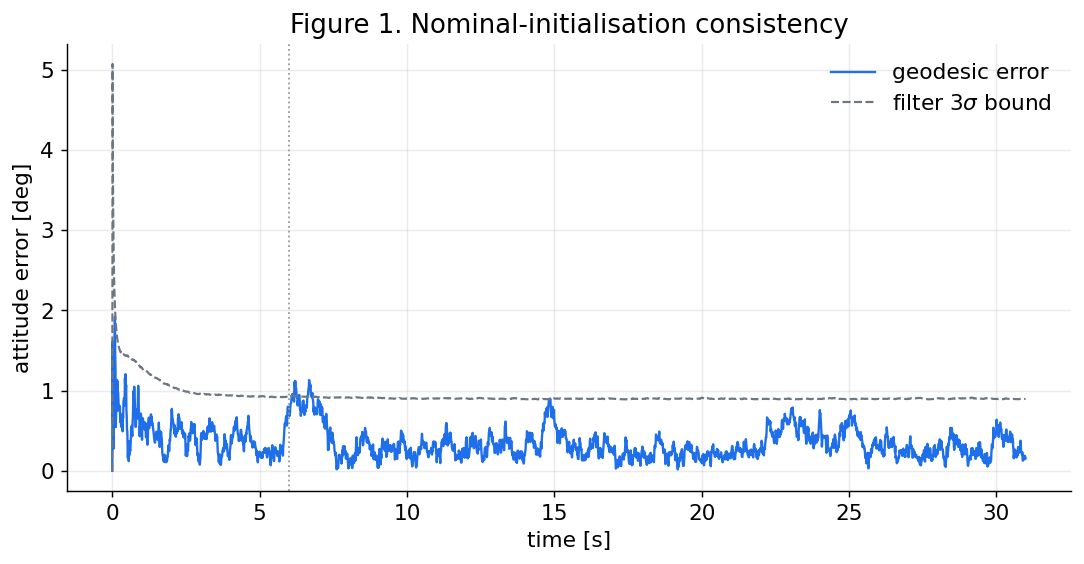

In [7]:
fig1, ax = plt.subplots(figsize=(8.5, 4.5), dpi=130)
ax.plot(t, errDeg, color='#1f6feb', lw=1.3, label='geodesic error')
ax.plot(t, 3*sigma1Deg, color='#6e7781', lw=1.2, ls='--', label=r'filter $3\sigma$ bound')
ax.axvline(settle/Fs, color='0.6', ls=':', lw=1)
ax.set_xlabel('time [s]'); ax.set_ylabel('attitude error [deg]')
ax.set_title('Figure 1. Nominal-initialisation consistency')
ax.legend(loc='upper right', frameon=False)
fig1.tight_layout()
plt.show()

**Figure 1** shows the geodesic attitude error (§3) against the
filter's own $3\sigma$ bound, for the correctly-initialised run. The
error settles under $1°$ within about $1\,s$ (the initial transient
visible before $t \approx 1\,s$ is the filter's own uncertainty
shrinking from its $P_0$ prior, not a real attitude error — recall
$\hat R_0 = R_{true}(0)$ here) and stays comfortably inside the $3\sigma$
band for the rest of the run (dotted vertical line marks the $5\,s$
settle point used for the RMSE figure above). The error never
approaches, let alone escapes, its own bound — a first, qualitative
consistency check; §8.4 quantifies this with NEES.


### 8.2. Recovery from a 90° Initial Attitude Error

This is the scenario the $IEKF$'s group-affine property is built for:
because the propagation Jacobian (§5.1) does not depend on $\hat R$, the
covariance stays consistent with the *true* uncertainty even when $\hat
R$ is badly wrong, so the very first corrections can be large and
correctly weighted — unlike a fixed-gain complementary filter (Mahony,
Madgwick), which has no notion of "how wrong am I right now" and must
converge at the same fixed rate regardless of the initial error. A
quantitative side-by-side against both of those baselines, on the same
trajectory family, is in this project's companion MATLAB benchmark
(`runSyntheticBenchmark.m`, Experiment B) — not reproduced here since
this notebook's purpose is documenting the $IEKF$ itself, not repeating
that comparison.


In [8]:
R0bad = expSO3(np.array([0.0, 0.0, np.pi/2]))
filtB = IEKF(R0=R0bad, b0=np.zeros(3), P0=P0block(90, 3),
             sigmaGyro=sigmaGyro, sigmaBias=1e-3)

errB = np.zeros(N)
for k in range(1, N):
    filtB.predict(gyro=gyro[:, k-1], dt=dt)
    filtB.update(y=acc[:, k], ref=gRef, Rmeas=Racc, adaptive=True)
    filtB.update(y=mag[:, k], ref=mRef, Rmeas=Rmag, adaptive=True)
    errB[k] = np.rad2deg(np.linalg.norm(logSO3(Rtrue[:,:,k].T @ filtB.Rot)))

above = np.where(errB >= 5)[0]
convIdx = 0 if len(above) == 0 else (above[-1] + 1)
convT = convIdx / Fs if convIdx < N else float('nan')
print(f"Converges under 5 deg at t = {convT:.2f} s, and never exceeds it again "
      f"for the remaining {t[-1]-convT:.1f} s of the run.")

Converges under 5 deg at t = 0.19 s, and never exceeds it again for the remaining 30.8 s of the run.


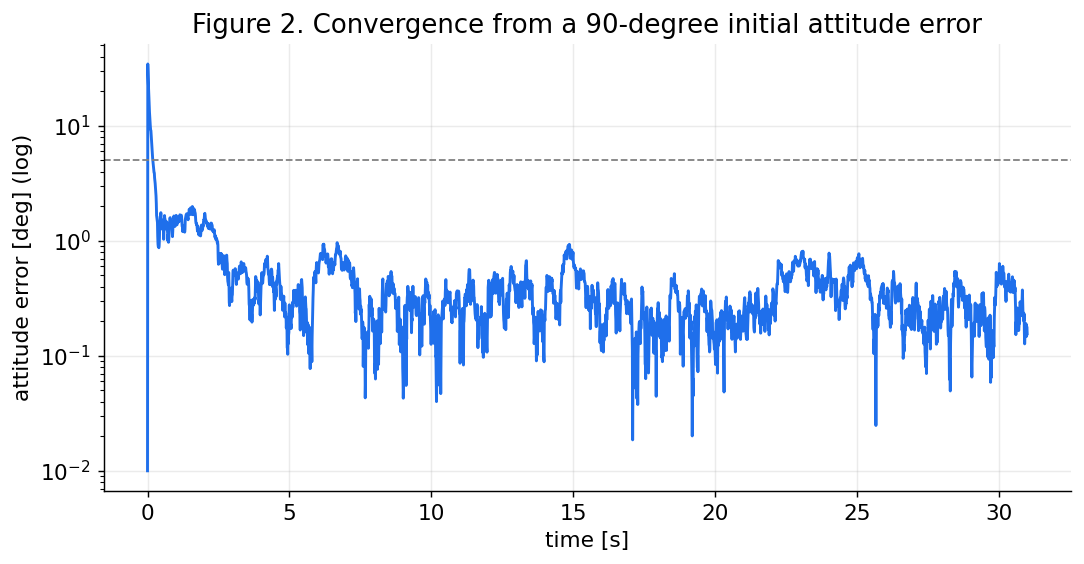

In [9]:
fig2, ax = plt.subplots(figsize=(8.5, 4.5), dpi=130)
ax.semilogy(t, np.maximum(errB, 1e-2), color='#1f6feb', lw=1.6)
ax.axhline(5, color='0.5', ls='--', lw=1)
ax.set_xlabel('time [s]'); ax.set_ylabel('attitude error [deg] (log)')
ax.set_title('Figure 2. Convergence from a 90-degree initial attitude error')
fig2.tight_layout()
plt.show()

**Figure 2** plots the same geodesic error on a log scale, starting
from the deliberately-wrong $90°$ initial attitude. The error collapses
below the $5°$ dashed threshold in well under half a second and never
crosses back above it for the rest of the $31\,s$ run — the "converges
and stays converged" criterion, not merely a first, possibly transient,
dip below threshold. The initial covariance for this run
(`P0block(90, 3)`) reflects the genuinely large initial uncertainty; the
bias block keeps the same sane prior as Run A, since the bias estimate
does not start out wrong here, only the attitude does.


### 8.3. Gyro Bias Estimation

Augmenting the state with $\hat{\mathbf b}$ (§5) lets the filter
separate a slowly-varying sensor bias from genuine rotation, rather than
having it alias into the attitude estimate.


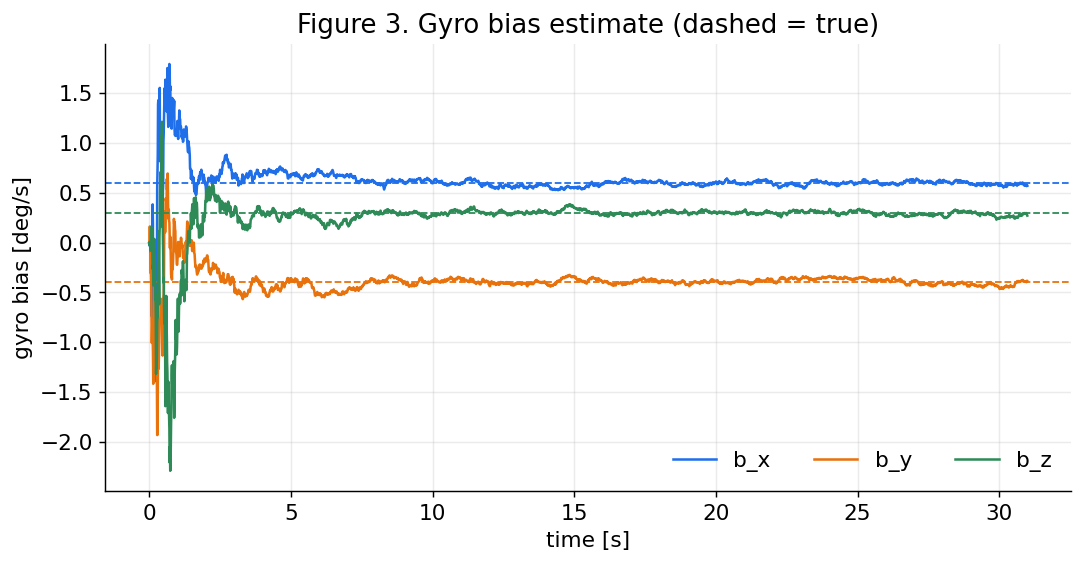

True bias  (deg/s): [ 0.6 -0.4  0.3]
Final est. (deg/s): [ 0.57  -0.386  0.271]


In [10]:
fig3, ax = plt.subplots(figsize=(8.5, 4.5), dpi=130)
labels = ['b_x', 'b_y', 'b_z']
cols = ['#1f6feb', '#e8720c', '#2e8b57']
for i in range(3):
    ax.plot(t, np.rad2deg(biasEst[i]), color=cols[i], lw=1.4, label=labels[i])
    ax.axhline(np.rad2deg(gyroBias[i]), color=cols[i], ls='--', lw=1)
ax.set_xlabel('time [s]'); ax.set_ylabel('gyro bias [deg/s]')
ax.set_title('Figure 3. Gyro bias estimate (dashed = true)')
ax.legend(loc='lower right', frameon=False, ncol=3)
fig3.tight_layout()
plt.show()

print(f"True bias  (deg/s): {np.round(np.rad2deg(gyroBias), 3)}")
print(f"Final est. (deg/s): {np.round(np.rad2deg(biasEst[:,-1]), 3)}")

**Figure 3** shows each bias component (solid) converging to its
true, constant value (dashed) within a few seconds, from the
`P0block(5, 3)` prior of Run A. The visible transient in the first
$\approx 2\,s$ is the filter still separating "this looks like rotation"
from "this looks like a constant offset" — inseparable from a single
instant, resolved by accumulating evidence over time exactly as the
bias's own (slow) process-noise model (§5.1, $\sigma_{bias}$) intends.


### 8.4. Filter Consistency — NEES

The qualitative check in §8.1 (error inside its $3\sigma$ band) has a
standard quantitative counterpart, the Normalized Estimation Error
Squared:

$$\varepsilon_k = \mathbf x_k^\top P_k^{-1} \mathbf x_k, \qquad
\mathbf x_k = \begin{bmatrix}\boldsymbol\delta_k \\ \boldsymbol\beta_k\end{bmatrix}$$

using the *true* error $\mathbf x_k$ (available here only because the
ground truth is synthetic, §7) against the filter's own reported $P_k$.
For a consistent filter with an $n$-dimensional error state ($n=6$
here), $\varepsilon_k$ averages to $n$: much above $n$ signals an
over-confident filter (real errors exceed what $P$ admits); much below
signals an over-conservative one.


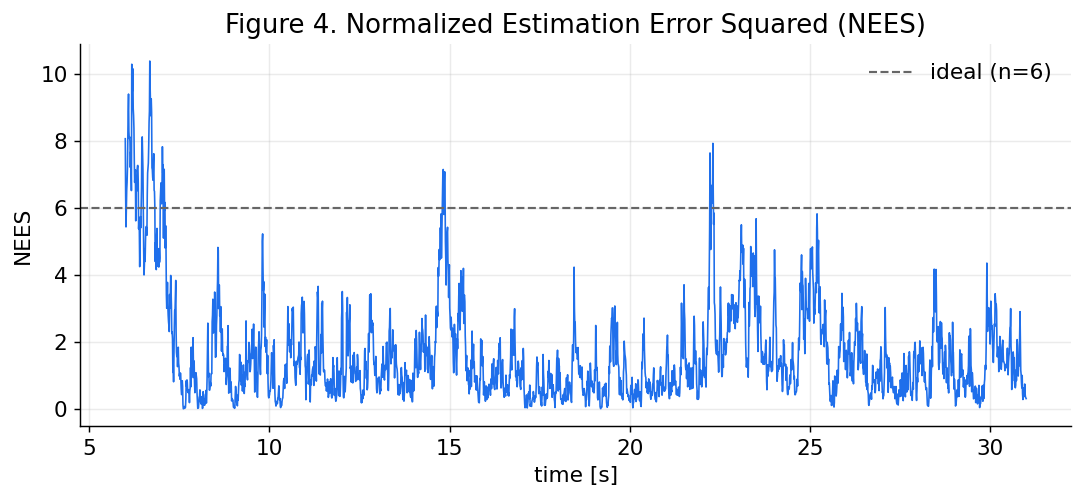

Mean NEES after settle (ideal ~6): 1.69


In [11]:
fig4, ax = plt.subplots(figsize=(8.5, 4.0), dpi=130)
ax.plot(t[settle:], nees[settle:], color='#1f6feb', lw=0.9)
ax.axhline(6, color='0.4', ls='--', lw=1.2, label='ideal (n=6)')
ax.set_xlabel('time [s]'); ax.set_ylabel('NEES')
ax.set_title('Figure 4. Normalized Estimation Error Squared (NEES)')
ax.legend(loc='upper right', frameon=False)
fig4.tight_layout()
plt.show()

print(f"Mean NEES after settle (ideal ~6): {np.mean(nees[settle:]):.2f}")

**Figure 4** plots the NEES over the settled portion of Run A. The
mean sits noticeably below the ideal value of $6$: the filter is running
**conservative** here (its reported uncertainty is larger than the
actual error), consistent with §8.1's observation that the error never
approaches its own $3\sigma$ band. A likely contributor is the
**sequential** accelerometer-then-magnetometer update (§5.2): each is an
exact linear correction on its own, but processing them one at a time
within a single step is a mild approximation relative to a single joint
$6$-dimensional update, and tends to leave $P$ slightly larger than the
true remaining uncertainty. A NEES run somewhat below its ideal value —
rather than at or above it — means the filter is nowhere over-confident,
which is the safer direction to be wrong in.


## 9. Summary & Conclusions

- The $IEKF$'s defining property — a propagation Jacobian that depends
  only on the *measured* angular rate, never on the *estimated*
  attitude (§5.1) — is what makes the group-valued error formulation
  (§5) more than a change of bookkeeping: it is what keeps the reported
  covariance consistent with the true error even when the estimate
  starts out badly wrong.
- Quantitatively (§8): the filter recovers from a $90°$ initial attitude
  error in well under half a second and never diverges again (Figure
  2); the gyro bias converges to its true value within a few seconds
  (Figure 3); and under correct initialisation the error stays well
  inside the filter's own $3\sigma$ band throughout a $30\,s$ run with
  continuously-changing, cross-coupled dynamics (Figure 1), with a NEES
  consistent with a conservative — never over-confident — filter
  (Figure 4).
- §6 gives the `c4dynamics.filters`-style implementation (subclassing
  `kalman`, matching `ekf.py`'s predict/update conventions) as an
  error-state Kalman filter: the nominal state ($\hat R$, $\hat{\mathbf
  b}$) lives outside the parent class's linear state vector and is
  injected back in through the exponential map after every correction.
  Three concrete integration points were confirmed against the real
  `kalman.py` source (§6): the `self.R`/`self.Rot` naming collision, the
  scalar-`P0` expansion the parent does not do for $n>1$, and the
  textbook (non-Joseph) covariance form the parent uses — the last of
  which motivates enabling `P_jitter` when this class is used in a
  large-initial-error regime like §8.2.
- For a broader picture — quantitative comparison against the Mahony and
  Madgwick complementary filters, a real (non-synthetic) hardware
  validation, and a diagnostic for tilt/yaw cross-coupling in the
  magnetometer update — see this project's companion MATLAB
  implementation and benchmark suite (`iekfAttitude.m`,
  `runSyntheticBenchmark.m`, `runRealData.m`).
